# 3: Classical and Advanced Modeling

This notebook trains and evaluates several supervised models using the Gold dataset created in Notebook 2.

Inputs:
- `data/gold/X_train.parquet`
- `data/gold/X_test.parquet`
- `data/gold/y_train.parquet`
- `data/gold/y_test.parquet`
- `data/gold/feature_config.json`

Outputs:
- `reports/tables/model_comparison.csv`
- `reports/tables/classification_report_best_model.csv`
- `reports/figures/model_comparison.png`
- `reports/figures/confusion_matrix_best_model.png`
- `models/best_classical_pipeline.pkl`
- `models/model_metadata.json`

The task is a binary supervised classification problem based on a proxy target:

- `0`: listing declares a license.
- `1`: listing does not declare a license and is treated as potentially unlicensed.

This is not confirmed legal fraud. It is a proxy for possible regulatory non-compliance.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
def find_project_root(start_path=None, project_folder_name="tool"):
    current_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    for path in [current_path] + list(current_path.parents):
        if path.name == project_folder_name:
            return path

    raise RuntimeError(
        f"Could not find project root folder named '{project_folder_name}'. "
        f"Current working directory is: {Path.cwd()}"
    )


PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "data"
GOLD_DIR = DATA_DIR / "gold"

REPORTS_DIR = PROJECT_DIR / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

X_TRAIN_PATH = GOLD_DIR / "X_train.parquet"
X_TEST_PATH = GOLD_DIR / "X_test.parquet"
X_VAL_PATH = GOLD_DIR / "X_val.parquet"

Y_TRAIN_PATH = GOLD_DIR / "y_train.parquet"
Y_TEST_PATH = GOLD_DIR / "y_test.parquet"
Y_VAL_PATH = GOLD_DIR / "y_val.parquet"

FEATURE_CONFIG_PATH = GOLD_DIR / "feature_config.json"

MODEL_COMPARISON_PATH = TABLES_DIR / "model_comparison.csv"
CLASSIFICATION_REPORT_PATH = TABLES_DIR / "classification_report_best_model.csv"

MODEL_COMPARISON_FIG_PATH = FIGURES_DIR / "model_comparison.png"
CONFUSION_MATRIX_FIG_PATH = FIGURES_DIR / "confusion_matrix_best_model.png"

BEST_MODEL_PATH = MODELS_DIR / "best_classical_pipeline.pkl"
MODEL_METADATA_PATH = MODELS_DIR / "model_metadata.json"
MLP_MODEL_PATH = MODELS_DIR / "mlp_tabular_model.keras"

for directory in [TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool


In [3]:
X_train = pd.read_parquet(X_TRAIN_PATH)
X_val = pd.read_parquet(X_VAL_PATH)
X_test = pd.read_parquet(X_TEST_PATH)

y_train = pd.read_parquet(Y_TRAIN_PATH).iloc[:, 0]
y_val = pd.read_parquet(Y_VAL_PATH).iloc[:, 0]
y_test = pd.read_parquet(Y_TEST_PATH).iloc[:, 0]

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as file:
    feature_config = json.load(file)

numeric_features = feature_config["numeric_features"]
categorical_features = feature_config["categorical_features"]
text_features = feature_config.get("text_features", ["text"])
selected_features = feature_config["selected_features"]
target_col = feature_config["target"]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Text features:", len(text_features))
print("Total features:", len(selected_features))
print("Target:", target_col)

display(X_train.head())

X_train shape: (9165, 24)
X_val shape: (3056, 24)
X_test shape: (3055, 24)
y_train shape: (9165,)
y_val shape: (3056,)
y_test shape: (3055,)

Numeric features: 21
Categorical features: 2
Text features: 1
Total features: 24
Target: potentially_unlicensed


,log_price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,word_count,uppercase_ratio,digit_count,exclamation_count,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,licenses_within_250m,licenses_within_500m,has_license_within_100m,has_license_within_250m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2,property_type,neighbourhood,text
0,4.204693,1,27,13,0.49,6,1,5,0.083333,0,0,75.834589,3.0,1.0,30.0,135.0,1.0,1.0,1.0,152.788745,171.887339,Private room,Sants,Double room in Art apartment
1,5.327876,2,210,503,3.65,59,1,7,0.171429,0,0,26.783170,6.0,14.0,72.0,232.0,1.0,1.0,1.0,366.692989,295.391574,Entire home/apt,"Sant Pere, Santa Caterina i la Ribera",Center apartment with SUPER king size bed
2,5.176150,2,253,36,1.55,19,10,7,0.117647,3,0,35.322915,4.0,1.0,6.0,81.0,1.0,1.0,1.0,30.557749,103.132403,Entire home/apt,Sant Gervasi - Galvany,204 Precioso Apt. Con servicios en Barcelona
3,5.093750,32,69,45,8.39,45,9,6,0.172414,0,0,52.886426,6.0,3.0,12.0,165.0,1.0,1.0,1.0,61.115498,210.084525,Private room,el Raval,Timeless Double Room at Las Rambla
4,4.127134,31,325,4,0.15,0,1,6,0.151515,0,0,48.313603,11.0,20.0,80.0,164.0,1.0,1.0,1.0,407.436654,208.811285,Entire home/apt,el Raval,Entire Apartment Center -up Metro Liceu-


In [4]:
if list(X_train.columns) != selected_features:
    raise ValueError("X_train columns do not match selected_features from feature_config.")

if list(X_test.columns) != selected_features:
    raise ValueError("X_test columns do not match selected_features from feature_config.")

if not set(y_train.unique()).issubset({0, 1}):
    raise ValueError("y_train must contain only binary values 0 and 1.")

if not set(y_test.unique()).issubset({0, 1}):
    raise ValueError("y_test must contain only binary values 0 and 1.")

print("Gold train/test datasets are valid.")

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

Gold train/test datasets are valid.

Train target distribution:


,proportion
potentially_unlicensed,
0,0.768685
1,0.231315



Test target distribution:


,proportion
potentially_unlicensed,
0,0.768576
1,0.231424


## Specific modelling preprocessing:
To imput the model the variables we need one last transformation specific for ml models, numeric variables will be standardised using StandartScaler and categorical variables will be encoded using OneHotEncoder

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Auxiliar Functions:
Thi function usage will be explained later

In [6]:
def evaluate_scores(y_true, y_score, threshold=0.5):
    """
    Evaluate probabilistic scores using a fixed threshold.
    """
    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

    return metrics, y_pred



def get_model_scores(model, X):
    """
    Return continuous risk scores for the positive class.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)




def find_best_threshold_by_f1(y_true, y_score, thresholds=None):
    """
    Find the threshold that maximizes F1-score on the validation set.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    threshold_results = []

    for threshold in thresholds:
        metrics, _ = evaluate_scores(
            y_true=y_true,
            y_score=y_score,
            threshold=threshold,
        )

        threshold_results.append({
            "threshold": threshold,
            **metrics,
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_row = (
        threshold_df
        .sort_values(["f1", "precision", "recall"], ascending=False)
        .iloc[0]
    )

    return float(best_row["threshold"]), best_row, threshold_df

# Model selection

The project evaluates a compact but meaningful set of models.

The goal is not to test every possible algorithm. The goal is to compare models with different assumptions:

1. A naive baseline.
2. A linear interpretable model.
3. A robust non-linear ensemble.
4. A modern boosting model from scikit-learn.
5. A stronger state-of-the-art boosting model.
6. A neural network as an advanced comparison.

All models use the same train/test split and the same evaluation metrics.

## 1 DummyClassifier: baseline model

The DummyClassifier is included as a naive baseline.

It does not learn patterns from the data. It simply predicts the most frequent class in the training set.

This model is necessary because it tells us whether the real machine learning models are actually adding value. If a model does not outperform this baseline, then the engineered features and modeling process are not useful.

In this project, the DummyClassifier answers a simple question:

> Are we learning meaningful patterns, or are we only reflecting the class distribution?

In [7]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

## 2 Logistic Regression: interpretable linear baseline

Logistic Regression is used as a simple and interpretable supervised model.

It tests whether the target can be predicted with approximately linear relationships between the features and the class label.

This is useful because it gives a transparent benchmark before using more complex models. If non-linear models perform much better, that suggests the problem depends on interactions between variables such as price, property type, review activity and license proximity.

In [8]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## 3 Random Forest: robust non-linear ensemble

Random Forest is selected because it is a strong and robust classical model for tabular data.

It combines many decision trees and can capture non-linear relationships and interactions between features.

This is relevant because the risk proxy may depend on combinations of variables, for example:

- price level;
- property type;
- activity indicators;
- review behaviour;
- proximity to official licenses.

Random Forest also works well with mixed tabular features and can later be interpreted with permutation importance.

In [9]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

## 4 HistGradientBoosting: modern boosting model from scikit-learn

HistGradientBoosting is a modern gradient boosting model available directly in scikit-learn.

Boosting models build trees sequentially. Each new tree tries to correct errors made by the previous ones, which often makes them very strong on structured tabular data.

This model is included as a more advanced classical machine learning approach while keeping the implementation within the scikit-learn ecosystem.

In [10]:
hist_gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## 5 XGBoost: state-of-the-art gradient boosting model

XGBoost is included as a stronger gradient boosting model for tabular data.

It is widely used in practical machine learning because it can model complex non-linear relationships and includes regularization mechanisms to reduce overfitting.

In this project, XGBoost serves as the strongest classical model candidate. It helps evaluate whether a more specialized boosting algorithm improves over Random Forest and HistGradientBoosting.

In [11]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.32311320754717


# Train classical models

The following cell trains all classical models using the same Gold train/test split.


In [12]:
classical_models = {
    "dummy_most_frequent": dummy_pipeline,
    "logistic_regression": logistic_pipeline,
    "random_forest": random_forest_pipeline,
    "hist_gradient_boosting": hist_gradient_boosting_pipeline,
    "xgboost": xgboost_pipeline,
}

trained_models = {}
results = []
threshold_tables = {}

for model_name, pipeline in classical_models.items():
    print(f"Training {model_name}...")

    pipeline.fit(X_train, y_train)

    # Validation scores: used only to choose threshold
    y_val_score = get_model_scores(pipeline, X_val)

    best_threshold, best_threshold_row, threshold_df = find_best_threshold_by_f1(
        y_true=y_val.values,
        y_score=y_val_score,
    )

    # Test scores: final evaluation using validation-selected threshold
    y_test_score = get_model_scores(pipeline, X_test)

    test_metrics, y_test_pred = evaluate_scores(
        y_true=y_test.values,
        y_score=y_test_score,
        threshold=best_threshold,
    )

    trained_models[model_name] = {
        "pipeline": pipeline,
        "best_threshold": best_threshold,
        "validation_threshold_results": threshold_df,
        "test_metrics": test_metrics,
        "y_pred": y_test_pred,
        "y_score": y_test_score,
    }

    threshold_tables[model_name] = threshold_df

    results.append({
        "model": model_name,
        "model_family": "baseline" if model_name == "dummy_most_frequent" else "classical_ml",
        "selected_threshold": best_threshold,
        **test_metrics,
    })

classical_model_comparison = (
    pd.DataFrame(results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)


display(classical_model_comparison)

Training dummy_most_frequent...
Training logistic_regression...
Training random_forest...
Training hist_gradient_boosting...
Training xgboost...


,model,model_family,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,classical_ml,0.37,0.875941,0.684270,0.861386,0.762680,0.935116,0.807779
1,hist_gradient_boosting,classical_ml,0.42,0.877578,0.697979,0.830269,0.758398,0.935984,0.805213
2,xgboost,classical_ml,0.62,0.866448,0.659212,0.875530,0.752126,0.931006,0.774151
3,logistic_regression,classical_ml,0.55,0.829787,0.586334,0.898161,0.709497,0.887526,0.588489
4,dummy_most_frequent,baseline,0.05,0.768576,0.000000,0.000000,0.000000,0.500000,0.231424


# NLP model: TF-IDF + Logistic Regression

This model introduces a real NLP component into the project.

The previous classical models use structured tabular features, including objective text-derived variables such as word count, uppercase ratio or digit count. However, those variables do not use the actual words appearing in the listing title.

TF-IDF transforms the raw listing text into numerical features based on term frequency and inverse document frequency. This allows the model to learn whether specific words or short expressions are associated with the proxy target.

Logistic Regression is used because it is simple, fast and interpretable. It is a good first NLP model before moving to more complex neural architectures.

This model combines:

- tabular Gold features;
- one-hot encoded categorical variables;
- TF-IDF features extracted from the raw listing text.

In [13]:
X_train["text"] = X_train["text"].astype(str)
X_test["text"] = X_test["text"].astype(str)

## TF-IDF preprocessing: Decisions
Numeric features are scaled, categorical features are one-hot encoded, and the raw text field is transformed using TF-IDF. The TF-IDF vectorizer uses unigrams and bigrams to capture simple word-level and phrase-level information from Airbnb listing titles.

In [14]:

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=5000,
)

nlp_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("text", tfidf_vectorizer, "text"),
    ],
    sparse_threshold=0.3,
)

In [15]:
tfidf_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", nlp_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="saga",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [16]:
print("Training tfidf_logistic_regression...")

tfidf_logistic_pipeline.fit(X_train, y_train)

# Validation threshold selection
tfidf_val_score = get_model_scores(tfidf_logistic_pipeline, X_val)

tfidf_best_threshold, tfidf_best_threshold_row, tfidf_threshold_df = find_best_threshold_by_f1(
    y_true=y_val.values,
    y_score=tfidf_val_score,
)

# Final test evaluation
tfidf_test_score = get_model_scores(tfidf_logistic_pipeline, X_test)

tfidf_metrics, tfidf_y_pred = evaluate_scores(
    y_true=y_test.values,
    y_score=tfidf_test_score,
    threshold=tfidf_best_threshold,
)

tfidf_result = {
    "model": "tfidf_logistic_regression",
    "model_family": "nlp_ml",
    "selected_threshold": tfidf_best_threshold,
    **tfidf_metrics,
}

display(pd.DataFrame([tfidf_result]))

trained_models["tfidf_logistic_regression"] = {
    "pipeline": tfidf_logistic_pipeline,
    "best_threshold": tfidf_best_threshold,
    "validation_threshold_results": tfidf_threshold_df,
    "test_metrics": tfidf_metrics,
    "y_pred": tfidf_y_pred,
    "y_score": tfidf_test_score,
}

threshold_tables["tfidf_logistic_regression"] = tfidf_threshold_df

Training tfidf_logistic_regression...


,model,model_family,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,tfidf_logistic_regression,nlp_ml,0.54,0.836989,0.601555,0.87553,0.713134,0.902495,0.660149


# Advanced model: Simple two-layer neural network

This model is a simple feed-forward neural network applied to the tabular Gold dataset.

It is included as an advanced comparison model. The objective is not to build a complex deep learning architecture, but to evaluate whether a small neural network can learn useful non-linear combinations of the structured features.

The network uses:
- the same numeric and categorical variables as the classical tabular models;
- a preprocessing step that scales numeric variables and one-hot encodes categorical variables;
- two dense hidden layers;
- a sigmoid output for binary classification.

The output score is interpreted as the estimated probability of belonging to the `potentially_unlicensed` class.

Similarly to the tf-idf, we need to ensure the input types of the layers have the correct type and are scaled or encoded

In [17]:
X_train_tabular = X_train[numeric_features + categorical_features].copy()
X_val_tabular = X_val[numeric_features + categorical_features].copy()
X_test_tabular = X_test[numeric_features + categorical_features].copy()

dl_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_train_dl = dl_preprocessor.fit_transform(X_train_tabular)
X_val_dl = dl_preprocessor.transform(X_val_tabular)
X_test_dl = dl_preprocessor.transform(X_test_tabular)

X_train_dl = X_train_dl.astype("float32")
X_val_dl = X_val_dl.astype("float32")
X_test_dl = X_test_dl.astype("float32")

y_train_dl = y_train.astype("float32").values
y_val_dl = y_val.astype("float32").values
y_test_dl = y_test.astype("float32").values

print("X_train_dl shape:", X_train_dl.shape)
print("X_val_dl shape:", X_val_dl.shape)
print("X_test_dl shape:", X_test_dl.shape)

X_train_dl shape: (9165, 96)
X_val_dl shape: (3056, 96)
X_test_dl shape: (3055, 96)


We define our neural network, in our case we selected a simple 2 layers version of ReLu of 64 and 32 neurons and the output layer using a sigmoid

In [18]:
simple_nn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_dl.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.25),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(1, activation="sigmoid"),
    ]
)

simple_nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

simple_nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,321 (32.50 KB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 0 (0.00 B)

Model training

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = simple_nn_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7705 - loss: 0.4407 - pr_auc: 0.4671 - precision: 0.5084 - recall: 0.2429 - roc_auc: 0.7941 - val_accuracy: 0.8295 - val_loss: 0.3425 - val_pr_auc: 0.6166 - val_precision: 0.6118 - val_recall: 0.7199 - val_roc_auc: 0.8903
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8238 - loss: 0.3458 - pr_auc: 0.6021 - precision: 0.6189 - recall: 0.6198 - roc_auc: 0.8827 - val_accuracy: 0.8361 - val_loss: 0.3212 - val_pr_auc: 0.6349 - val_precision: 0.6071 - val_recall: 0.8260 - val_roc_auc: 0.8995
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8294 - loss: 0.3268 - pr_auc: 0.6233 - precision: 0.6196 - recall: 0.6792 - roc_auc: 0.8922 - val_accuracy: 0.8367 - val_loss: 0.3099 - val_pr_auc: 0.6535 - val_precision: 0.6072 - val_recall: 0.8331 - val_roc_auc: 0.9042
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8376 - loss: 0.3148 - pr_auc: 0.6328 - precision: 0.6248 - recall: 0.7

In [20]:
# Validation scores for threshold selection
nn_val_score = simple_nn_model.predict(X_val_dl).ravel()

nn_best_threshold, nn_best_threshold_row, nn_threshold_df = find_best_threshold_by_f1(
    y_true=y_val.values,
    y_score=nn_val_score,
)

# Test scores for final evaluation
nn_test_score = simple_nn_model.predict(X_test_dl).ravel()

nn_metrics, nn_y_pred = evaluate_scores(
    y_true=y_test.values,
    y_score=nn_test_score,
    threshold=nn_best_threshold,
)

nn_result = {
    "model": "simple_neural_network",
    "model_family": "deep_learning",
    "selected_threshold": nn_best_threshold,
    **nn_metrics,
}

display(pd.DataFrame([nn_result]))

threshold_tables["simple_neural_network"] = nn_threshold_df

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step


,model,model_family,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,simple_neural_network,deep_learning,0.4,0.843863,0.614087,0.87553,0.721866,0.912325,0.728188


# Model comparison metrics

This section compares all trained models using the same test set.

The target for evaluation is binary:

- `0`: declared license;
- `1`: potentially unlicensed.

The following metrics are used:

- **Accuracy**: proportion of total correct predictions. It gives a general view of performance, but it may be misleading if one class dominates.
- **Precision**: among listings predicted as `potentially_unlicensed`, the proportion that actually belong to that class. High precision means fewer false positives.
- **Recall**: among all real `potentially_unlicensed` listings, the proportion detected by the model. High recall means fewer false negatives.
- **F1-score**: harmonic mean of precision and recall. It is used as the main comparison metric because the project needs a balance between detecting potentially unlicensed listings and avoiding too many false alarms.
- **ROC-AUC**: measures how well the model ranks positive examples above negative examples across all classification thresholds.
- **PR-AUC**: measures the quality of the precision-recall trade-off and is especially useful when focusing on the positive class.

The final model will be selected mainly using F1-score, while ROC-AUC and PR-AUC are used as complementary ranking-quality metrics.

## Default threshold vs validation-selected threshold

Most classification models produce a continuous score between 0 and 1. By default, this score is often converted into a binary prediction using a threshold of `0.50`.

However, this default threshold is not necessarily optimal for the objective of this project. Since the positive class represents `potentially_unlicensed` listings, the project needs to balance precision and recall.

For this reason, each model is first evaluated with the default threshold and then evaluated again using a threshold selected on the validation set by maximizing F1-score.

The test set is only used for final evaluation, not for threshold selection.

In [21]:
default_threshold_results = []

# Sklearn-compatible models stored in trained_models
for model_name, model_info in trained_models.items():
    y_score = model_info["y_score"]

    metrics_default, y_pred_default = evaluate_scores(
        y_true=y_test.values,
        y_score=y_score,
        threshold=0.50,
    )

    if model_name == "dummy_most_frequent":
        model_family = "baseline"
    elif model_name == "tfidf_logistic_regression":
        model_family = "nlp_ml"
    else:
        model_family = "classical_ml"

    default_threshold_results.append({
        "model": model_name,
        "model_family": model_family,
        "threshold": 0.50,
        **metrics_default,
    })

# Neural network
nn_metrics_default, nn_pred_default = evaluate_scores(
    y_true=y_test.values,
    y_score=nn_test_score,
    threshold=0.50,
)

default_threshold_results.append({
    "model": "simple_neural_network",
    "model_family": "deep_learning",
    "threshold": 0.50,
    **nn_metrics_default,
})

default_threshold_comparison = (
    pd.DataFrame(default_threshold_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(default_threshold_comparison)

DEFAULT_THRESHOLD_COMPARISON_PATH = TABLES_DIR / "model_comparison_default_threshold_050.csv"

default_threshold_comparison.to_csv(
    DEFAULT_THRESHOLD_COMPARISON_PATH,
    index=False,
)

print("Saved:", DEFAULT_THRESHOLD_COMPARISON_PATH)

,model,model_family,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,xgboost,classical_ml,0.5,0.854010,0.624880,0.923621,0.745434,0.931006,0.774151
1,hist_gradient_boosting,classical_ml,0.5,0.877905,0.726902,0.756719,0.741511,0.935984,0.805213
2,random_forest,classical_ml,0.5,0.879869,0.754491,0.712871,0.733091,0.935116,0.807779
3,tfidf_logistic_regression,nlp_ml,0.5,0.832733,0.591248,0.898161,0.713083,0.902495,0.660149
4,logistic_regression,classical_ml,0.5,0.823568,0.575134,0.909477,0.704658,0.887526,0.588489
5,simple_neural_network,deep_learning,0.5,0.842226,0.630058,0.770863,0.693384,0.912325,0.728188
6,dummy_most_frequent,baseline,0.5,0.768576,0.000000,0.000000,0.000000,0.500000,0.231424


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\model_comparison_default_threshold_050.csv


## Model compairason

In [22]:
all_model_results = []

for model_name, model_info in trained_models.items():
    if model_name == "dummy_most_frequent":
        model_family = "baseline"
    elif model_name == "tfidf_logistic_regression":
        model_family = "nlp_ml"
    else:
        model_family = "classical_ml"

    all_model_results.append({
        "model": model_name,
        "model_family": model_family,
        "selected_threshold": model_info["best_threshold"],
        **model_info["test_metrics"],
    })

all_model_results.append(nn_result)

model_comparison = (
    pd.DataFrame(all_model_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
]

model_comparison = model_comparison[
    ["model", "model_family", "selected_threshold"] + metric_columns
]

display(model_comparison)

model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)

,model,model_family,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,classical_ml,0.37,0.875941,0.684270,0.861386,0.762680,0.935116,0.807779
1,hist_gradient_boosting,classical_ml,0.42,0.877578,0.697979,0.830269,0.758398,0.935984,0.805213
2,xgboost,classical_ml,0.62,0.866448,0.659212,0.875530,0.752126,0.931006,0.774151
3,simple_neural_network,deep_learning,0.40,0.843863,0.614087,0.875530,0.721866,0.912325,0.728188
4,tfidf_logistic_regression,nlp_ml,0.54,0.836989,0.601555,0.875530,0.713134,0.902495,0.660149
5,logistic_regression,classical_ml,0.55,0.829787,0.586334,0.898161,0.709497,0.887526,0.588489
6,dummy_most_frequent,baseline,0.05,0.768576,0.000000,0.000000,0.000000,0.500000,0.231424


In [23]:
# ============================================================
# DEFAULT VS VALIDATION-SELECTED THRESHOLD: F1 COMPARISON
# ============================================================

default_f1 = (
    default_threshold_comparison[["model", "f1"]]
    .rename(columns={"f1": "f1_default_threshold_050"})
)

optimized_f1 = (
    model_comparison[["model", "f1", "selected_threshold"]]
    .rename(columns={"f1": "f1_validation_selected_threshold"})
)

threshold_f1_comparison = default_f1.merge(
    optimized_f1,
    on="model",
    how="inner",
)

threshold_f1_comparison["f1_improvement"] = (
    threshold_f1_comparison["f1_validation_selected_threshold"]
    - threshold_f1_comparison["f1_default_threshold_050"]
)

threshold_f1_comparison = (
    threshold_f1_comparison
    .sort_values("f1_improvement", ascending=False)
    .reset_index(drop=True)
)

display(threshold_f1_comparison)

THRESHOLD_F1_COMPARISON_PATH = TABLES_DIR / "threshold_f1_improvement.csv"

threshold_f1_comparison.to_csv(
    THRESHOLD_F1_COMPARISON_PATH,
    index=False,
)

print("Saved:", THRESHOLD_F1_COMPARISON_PATH)

,model,f1_default_threshold_050,f1_validation_selected_threshold,selected_threshold,f1_improvement
0,random_forest,0.733091,0.762680,0.37,0.029589
1,simple_neural_network,0.693384,0.721866,0.40,0.028482
2,hist_gradient_boosting,0.741511,0.758398,0.42,0.016887
3,xgboost,0.745434,0.752126,0.62,0.006693
4,logistic_regression,0.704658,0.709497,0.55,0.004840
5,tfidf_logistic_regression,0.713083,0.713134,0.54,0.000051
6,dummy_most_frequent,0.000000,0.000000,0.05,0.000000


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\threshold_f1_improvement.csv


In [24]:
all_threshold_rows = []

for model_name, threshold_df in threshold_tables.items():
    temp_df = threshold_df.copy()
    temp_df["model"] = model_name
    all_threshold_rows.append(temp_df)

all_threshold_analysis = pd.concat(all_threshold_rows, ignore_index=True)

THRESHOLD_ANALYSIS_PATH = TABLES_DIR / "validation_threshold_analysis_all_models.csv"

all_threshold_analysis.to_csv(THRESHOLD_ANALYSIS_PATH, index=False)

display(all_threshold_analysis.head())

print("Saved:", THRESHOLD_ANALYSIS_PATH)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,model
0,0.05,0.768652,0.0,0.0,0.0,0.5,0.231348,dummy_most_frequent
1,0.06,0.768652,0.0,0.0,0.0,0.5,0.231348,dummy_most_frequent
2,0.07,0.768652,0.0,0.0,0.0,0.5,0.231348,dummy_most_frequent
3,0.08,0.768652,0.0,0.0,0.0,0.5,0.231348,dummy_most_frequent
4,0.09,0.768652,0.0,0.0,0.0,0.5,0.231348,dummy_most_frequent


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\validation_threshold_analysis_all_models.csv


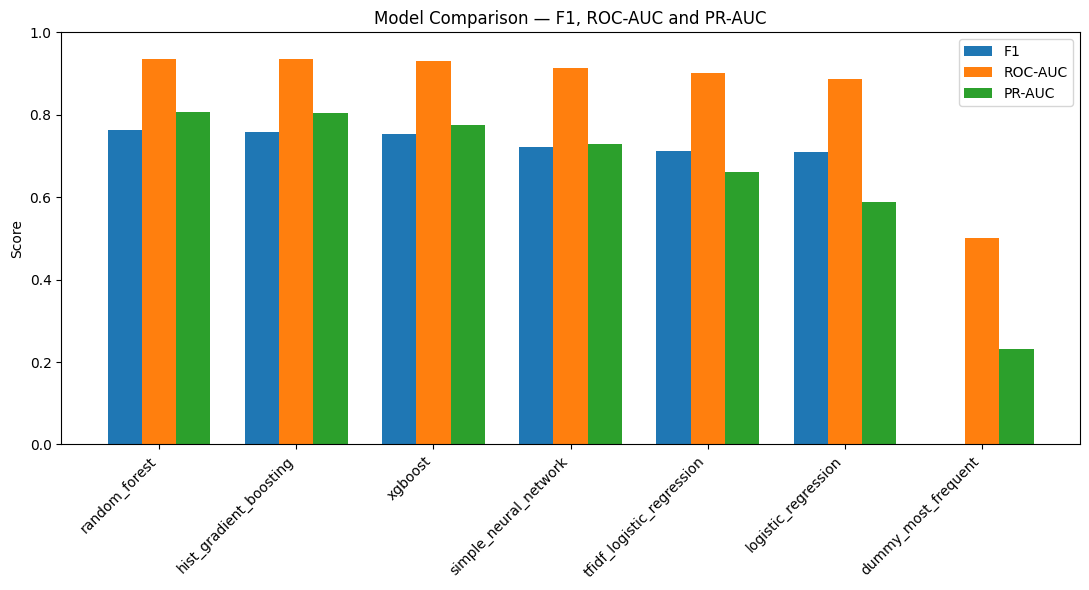

In [25]:
plot_df = model_comparison.set_index("model")[["f1", "roc_auc", "pr_auc"]]

plt.figure(figsize=(11, 6))

x = np.arange(len(plot_df.index))
width = 0.25

plt.bar(x - width, plot_df["f1"], width, label="F1")
plt.bar(x, plot_df["roc_auc"], width, label="ROC-AUC")
plt.bar(x + width, plot_df["pr_auc"], width, label="PR-AUC")

plt.xticks(x, plot_df.index, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Model Comparison — F1, ROC-AUC and PR-AUC")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(MODEL_COMPARISON_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

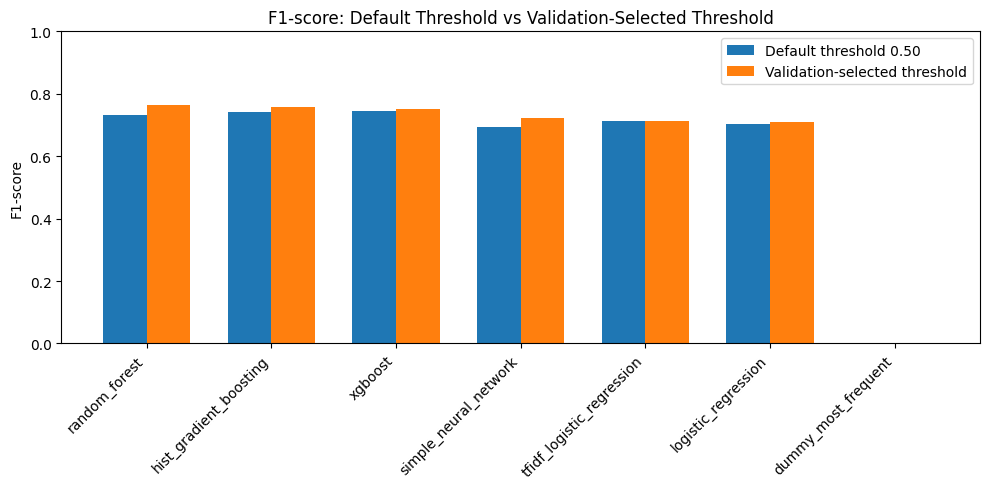

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\threshold_f1_comparison.png


In [26]:
plot_df = threshold_f1_comparison.sort_values(
    "f1_validation_selected_threshold",
    ascending=False,
).reset_index(drop=True)

plt.figure(figsize=(10, 5))

x = np.arange(len(plot_df))
width = 0.35

plt.bar(
    x - width / 2,
    plot_df["f1_default_threshold_050"],
    width,
    label="Default threshold 0.50",
)

plt.bar(
    x + width / 2,
    plot_df["f1_validation_selected_threshold"],
    width,
    label="Validation-selected threshold",
)

plt.xticks(x, plot_df["model"], rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("F1-score: Default Threshold vs Validation-Selected Threshold")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

THRESHOLD_F1_COMPARISON_FIG_PATH = FIGURES_DIR / "threshold_f1_comparison.png"

plt.savefig(
    THRESHOLD_F1_COMPARISON_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", THRESHOLD_F1_COMPARISON_FIG_PATH)

## Prediction and recall analysis

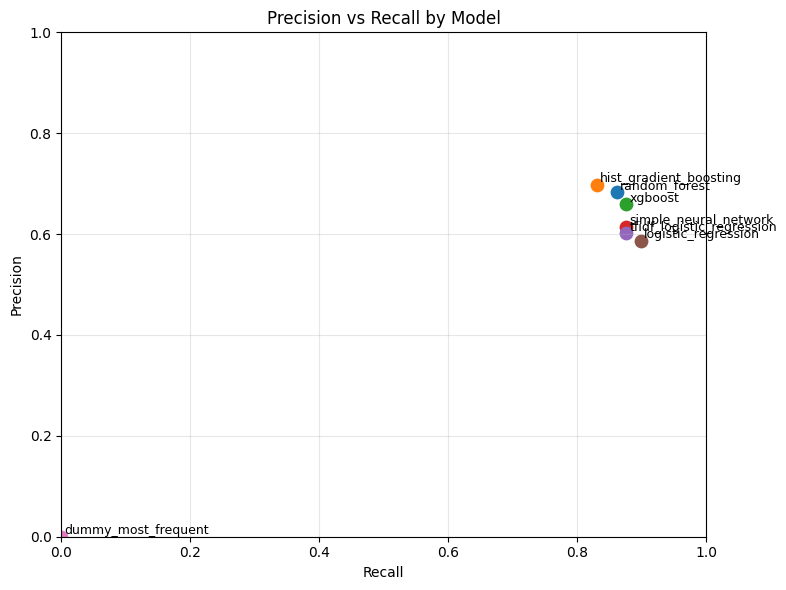

In [27]:
plt.figure(figsize=(8, 6))

for _, row in model_comparison.iterrows():
    plt.scatter(row["recall"], row["precision"], s=80)
    plt.text(
        row["recall"] + 0.005,
        row["precision"] + 0.005,
        row["model"],
        fontsize=9
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall by Model")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "precision_vs_recall_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Model evaluation conclusions

All real machine learning models clearly outperform the baseline. The baseline predicts only the majority class, which gives it zero precision, recall and F1-score for the potentially_unlicensed class. This confirms that accuracy alone is not enough for this project.

Random Forest achieves the best F1-score (0.7627) and the highest PR-AUC (0.8078). It also provides a strong balance between recall (0.8614) and precision (0.6843), meaning that it detects most positive proxy cases while keeping false positives relatively controlled.

HistGradientBoosting performs very similarly and obtains slightly higher accuracy and ROC-AUC, but its F1-score and PR-AUC are slightly lower. XGBoost achieves higher recall, but with lower precision, making it more aggressive and more prone to false positives.

The neural network and the Logistic Regression models achieve high recall but lower precision and PR-AUC. The TF-IDF model shows that the listing title contains some predictive signal, but it does not outperform the best tabular models.

Overall, Random Forest was selected as the final model because it offers the best balance between detection capacity, false-positive control, ranking quality and interpretability.

In [28]:
FINAL_MODEL_NAME = "random_forest"

final_model_info = trained_models[FINAL_MODEL_NAME]

final_model = final_model_info["pipeline"]
final_threshold = final_model_info["best_threshold"]
final_y_score = final_model_info["y_score"]
final_y_pred = final_model_info["y_pred"]
final_metrics = final_model_info["test_metrics"]

print("Final selected model:", FINAL_MODEL_NAME)
print("Selected threshold:", final_threshold)

print("\nRisk score range:")
print("min:", final_y_score.min())
print("max:", final_y_score.max())
print("mean:", final_y_score.mean())

display(pd.DataFrame([{
    "model": FINAL_MODEL_NAME,
    "selected_threshold": final_threshold,
    **final_metrics,
}]))

Final selected model: random_forest
Selected threshold: 0.37000000000000005

Risk score range:
min: 0.0
max: 0.995
mean: 0.22223076923076923


,model,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,0.37,0.875941,0.68427,0.861386,0.76268,0.935116,0.807779


# Risk score:

The model output is not interpreted only as a binary prediction. The main output is a continuous `risk_score`, defined as:

`risk_score = P(potentially_unlicensed = 1)`

A binary prediction is obtained only after applying a decision threshold.

In [29]:
risk_scoring_results = X_test.copy()

risk_scoring_results["true_label"] = y_test.values
risk_scoring_results["risk_score"] = final_y_score
risk_scoring_results["selected_threshold"] = final_threshold
risk_scoring_results["binary_prediction"] = final_y_pred

risk_scoring_results["risk_level"] = pd.cut(
    risk_scoring_results["risk_score"],
    bins=[-0.001, 0.33, 0.66, 1.0],
    labels=["low", "medium", "high"],
)

display(risk_scoring_results.head())

risk_level_summary = (
    risk_scoring_results["risk_level"]
    .value_counts()
    .rename("count")
    .to_frame()
)

risk_level_summary["proportion"] = (
    risk_scoring_results["risk_level"]
    .value_counts(normalize=True)
)

display(risk_level_summary)

RISK_SCORING_RESULTS_PATH = TABLES_DIR / "final_random_forest_risk_scores.csv"
RISK_LEVEL_SUMMARY_PATH = TABLES_DIR / "final_random_forest_risk_level_summary.csv"

risk_scoring_results.to_csv(RISK_SCORING_RESULTS_PATH, index=False)
risk_level_summary.to_csv(RISK_LEVEL_SUMMARY_PATH)

print("Saved:", RISK_SCORING_RESULTS_PATH)
print("Saved:", RISK_LEVEL_SUMMARY_PATH)

,log_price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,word_count,uppercase_ratio,digit_count,exclamation_count,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,licenses_within_250m,licenses_within_500m,has_license_within_100m,has_license_within_250m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2,property_type,neighbourhood,text,true_label,risk_score,selected_threshold,binary_prediction,risk_level
0,4.174387,32,264,11,0.32,2,14,6,0.162791,0,0,49.948822,4.0,3.0,30.0,155.0,1.0,1.0,1.0,152.788745,197.352129,Entire home/apt,el Barri Gòtic,"Great classic&renovated, TOP centrally located APT",0,0.470,0.37,1,medium
1,4.094345,1,33,12,0.21,2,17,6,0.029412,0,0,38.828451,13.0,6.0,49.0,175.0,1.0,1.0,1.0,249.554951,222.816920,Entire home/apt,el Barri Gòtic,Penthouse with therrace and double room,0,0.060,0.37,0,low
2,4.276666,32,336,0,0.00,0,44,6,0.080000,0,0,48.170319,5.0,2.0,11.0,42.0,1.0,1.0,1.0,56.022540,53.476061,Entire home/apt,el Putxet i el Farró,Bright & comfy apartment in Bcn,1,0.665,0.37,1,high
3,5.918894,1,326,5,0.10,1,15,7,0.764706,18,0,29.272964,5.0,22.0,161.0,404.0,1.0,1.0,1.0,819.966267,514.388776,Entire home/apt,la Vila de Gràcia,HUTB-000578 · HUTB-000578 · HUTB-000578 · Suite...,0,0.090,0.37,0,low
4,3.688879,31,365,0,0.00,0,1,6,0.093023,0,0,39.115694,5.0,9.0,99.0,369.0,1.0,1.0,1.0,504.202860,469.825392,Private room,la Vila de Gràcia,"Habitación individual en Gràcia, Barcelona Centro",1,0.745,0.37,1,high


,count,proportion
risk_level,,
low,2112,0.691326
medium,666,0.218003
high,277,0.090671


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_random_forest_risk_scores.csv
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_random_forest_risk_level_summary.csv


In [30]:
# ============================================================
# SAVE MODELS AND METADATA FOR EXPLAINABILITY NOTEBOOK
# ============================================================

FINAL_MODEL_PATH = MODELS_DIR / "final_random_forest_pipeline.pkl"
ALL_TRAINED_MODELS_PATH = MODELS_DIR / "trained_models.pkl"
FINAL_MODEL_METADATA_PATH = MODELS_DIR / "final_model_metadata.json"

joblib.dump(final_model, FINAL_MODEL_PATH)
joblib.dump(trained_models, ALL_TRAINED_MODELS_PATH)

# Save TF-IDF model separately
if "tfidf_logistic_regression" in trained_models:
    TFIDF_MODEL_PATH = MODELS_DIR / "tfidf_logistic_pipeline.pkl"
    joblib.dump(
        trained_models["tfidf_logistic_regression"]["pipeline"],
        TFIDF_MODEL_PATH,
    )
    print("Saved:", TFIDF_MODEL_PATH)

# Save neural network and its preprocessor
SIMPLE_NN_MODEL_PATH = MODELS_DIR / "simple_neural_network.keras"
SIMPLE_NN_PREPROCESSOR_PATH = MODELS_DIR / "simple_nn_preprocessor.pkl"

simple_nn_model.save(SIMPLE_NN_MODEL_PATH)
joblib.dump(dl_preprocessor, SIMPLE_NN_PREPROCESSOR_PATH)

final_model_metadata = {
    "final_model_name": FINAL_MODEL_NAME,
    "final_model_family": "classical_ml",
    "selected_threshold": float(final_threshold),
    "threshold_selection_set": "validation",
    "threshold_selection_metric": "f1",
    "target": target_col,
    "negative_class": "declared_license",
    "positive_class": "potentially_unlicensed",
    "risk_score_definition": "P(potentially_unlicensed = 1)",
    "binary_decision_rule": (
        f"prediction = 1 if risk_score >= {final_threshold:.2f} else 0"
    ),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "text_features": text_features,
    "selected_features": selected_features,
    "final_test_metrics": {
        metric: float(value)
        for metric, value in final_metrics.items()
    },
    "notes": (
        "The final model was selected after comparing all models on the test set "
        "using thresholds selected on the validation set. The test set was not used "
        "for threshold selection."
    ),
}

with open(FINAL_MODEL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(final_model_metadata, file, indent=4)

print("Saved:", FINAL_MODEL_PATH)
print("Saved:", ALL_TRAINED_MODELS_PATH)
print("Saved:", SIMPLE_NN_MODEL_PATH)
print("Saved:", SIMPLE_NN_PREPROCESSOR_PATH)
print("Saved:", FINAL_MODEL_METADATA_PATH)

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\tfidf_logistic_pipeline.pkl
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\final_random_forest_pipeline.pkl
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\trained_models.pkl
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\simple_neural_network.keras
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\simple_nn_preprocessor.pkl
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\models\final_model_metadata.json
